 **PERFORMACE COMPARISON :CNN VS RESNET VS FILTERED IMAGES**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# Basic CNN model
cnn_model = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
    ])


cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history = cnn_model.fit(x_train, y_train, epochs=10, batch_size=64,
                        validation_split=0.1, verbose=2)

test_loss, test_acc = cnn_model.evaluate(x_test, y_test, verbose=0)
print(f"CNN Accuracy: {test_acc:.4f}")

Epoch 1/10
844/844 - 21s - 25ms/step - accuracy: 0.9464 - loss: 0.1737 - val_accuracy: 0.9857 - val_loss: 0.0505
Epoch 2/10
844/844 - 5s - 5ms/step - accuracy: 0.9798 - loss: 0.0662 - val_accuracy: 0.9868 - val_loss: 0.0394
Epoch 3/10
844/844 - 5s - 5ms/step - accuracy: 0.9837 - loss: 0.0519 - val_accuracy: 0.9907 - val_loss: 0.0326
Epoch 4/10
844/844 - 5s - 6ms/step - accuracy: 0.9856 - loss: 0.0464 - val_accuracy: 0.9908 - val_loss: 0.0283
Epoch 5/10
844/844 - 5s - 5ms/step - accuracy: 0.9877 - loss: 0.0385 - val_accuracy: 0.9920 - val_loss: 0.0313
Epoch 6/10
844/844 - 5s - 6ms/step - accuracy: 0.9886 - loss: 0.0363 - val_accuracy: 0.9925 - val_loss: 0.0265
Epoch 7/10
844/844 - 5s - 5ms/step - accuracy: 0.9903 - loss: 0.0306 - val_accuracy: 0.9930 - val_loss: 0.0236
Epoch 8/10
844/844 - 5s - 5ms/step - accuracy: 0.9904 - loss: 0.0303 - val_accuracy: 0.9917 - val_loss: 0.0286
Epoch 9/10
844/844 - 5s - 6ms/step - accuracy: 0.9919 - loss: 0.0255 - val_accuracy: 0.9923 - val_loss: 0.0276

In [43]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,614,720 (9.97 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 1,742,678 (6.65 MB)

In [7]:
# Define a simple residual block
def residual_block(x, filters, kernel_size=3):
    shortcut = x

    # If channel dimensions don't match, use 1x1 conv to align
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding="same")(shortcut)

    x = layers.Conv2D(filters, kernel_size, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.add([shortcut, x])
    x = layers.ReLU()(x)
    return x

In [8]:
# Build ResNet-like model
inputs = layers.Input(shape=(28,28,1))
x = layers.Conv2D(32, (3,3), activation='relu', padding="same")(inputs)


In [9]:
# Add residual blocks
x = residual_block(x, 32)
x = layers.MaxPooling2D((2,2))(x)

x = residual_block(x, 64)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)

resnet_model = models.Model(inputs, outputs)

resnet_model.compile(optimizer="adam",
                     loss="sparse_categorical_crossentropy",
                     metrics=["accuracy"])

resnet_history = resnet_model.fit(x_train, y_train, epochs=5, batch_size=64,
                                  validation_split=0.1, verbose=2)

resnet_test_loss, resnet_test_acc = resnet_model.evaluate(x_test, y_test, verbose=0)
print(f"ResNet Accuracy: {resnet_test_acc:.4f}")

Epoch 1/5
844/844 - 13s - 15ms/step - accuracy: 0.9595 - loss: 0.1311 - val_accuracy: 0.9865 - val_loss: 0.0396
Epoch 2/5
844/844 - 5s - 6ms/step - accuracy: 0.9885 - loss: 0.0375 - val_accuracy: 0.9900 - val_loss: 0.0336
Epoch 3/5
844/844 - 6s - 7ms/step - accuracy: 0.9914 - loss: 0.0270 - val_accuracy: 0.9900 - val_loss: 0.0410
Epoch 4/5
844/844 - 5s - 6ms/step - accuracy: 0.9938 - loss: 0.0193 - val_accuracy: 0.9885 - val_loss: 0.0452
Epoch 5/5
844/844 - 6s - 7ms/step - accuracy: 0.9948 - loss: 0.0160 - val_accuracy: 0.9907 - val_loss: 0.0350
ResNet Accuracy: 0.9921


In [44]:
resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28,    │      9,248 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │      9,248 │ conv2d_5[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ conv2d_4[0][0],   │
│                     │ 32)               │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 28, 28,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 14, 14,    │      2,112 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │     36,928 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 14, 14,    │          0 │ conv2d_7[0][0],   │
│                     │ 64)               │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 14, 14,    │          0 │ add_1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 7, 7, 64)  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    401,536 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │      1,290 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,437,536 (5.48 MB)

 Trainable params: 479,178 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 958,358 (3.66 MB)

In [13]:
#Using  filters
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist


from scipy.signal import convolve2d

In [14]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize images
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

In [19]:
# Define Filters (Kernels)

filters = {
    "Sharpen": np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]]),

    "Blur": np.ones((3,3)) / 9.0,

    "Vertical Edge": np.array([[-1, 0, 1],
                               [-2, 0, 2],
                               [-1, 0, 1]]),

    "Horizontal Edge": np.array([[-1, -2, -1],
                                  [0, 0, 0],
                                  [1, 2, 1]]),

    "Gaussian Blur": (1/16.0) * np.array([[1, 2, 1],
                                          [2, 4, 2],
                                          [1, 2, 1]]),

    "Laplacian": np.array([[0, 1, 0],
                           [1,-4, 1],
                           [0, 1, 0]]),

    "Walsh-like (Diagonal)": np.array([[1, -1, 1],
                                       [-1, 1, -1],
                                       [1, -1, 1]])
}

In [20]:
def apply_filter_dataset(images, kernel):
    filtered = np.zeros_like(images)
    for i in range(len(images)):
        filtered[i] = convolve2d(images[i], kernel, mode="same", boundary="fill", fillvalue=0)
    return filtered

In [35]:
filter_accuracies = {}

for name, kernel in filters.items():
    print(f"Testing CNN on filter: {name}")

    # Apply filter to dataset
    x_test_filtered = apply_filter_dataset(x_test.squeeze(), kernel)
    x_test_filtered = x_test_filtered.reshape(-1, 28, 28, 1)

    # Evaluate with your CNN or ResNet model
    loss, acc = cnn_model.evaluate(x_test_filtered, y_test, verbose=0)

    filter_accuracies[name] = acc
    print(f"{name} Accuracy: {acc:.4f}\n")

Testing CNN on filter: Sharpen
Sharpen Accuracy: 0.9393

Testing CNN on filter: Blur
Blur Accuracy: 0.9806

Testing CNN on filter: Vertical Edge
Vertical Edge Accuracy: 0.3237

Testing CNN on filter: Horizontal Edge
Horizontal Edge Accuracy: 0.2424

Testing CNN on filter: Gaussian Blur
Gaussian Blur Accuracy: 0.9857

Testing CNN on filter: Laplacian
Laplacian Accuracy: 0.5794

Testing CNN on filter: Walsh-like (Diagonal)
Walsh-like (Diagonal) Accuracy: 0.3152



In [36]:
print("\n=== Accuracy Using All Filters ===\n")
for name, acc in filter_accuracies.items():
    print(f"{name:20s}: {acc:.4f}")


=== Accuracy Using All Filters ===

Sharpen             : 0.9393
Blur                : 0.9806
Vertical Edge       : 0.3237
Horizontal Edge     : 0.2424
Gaussian Blur       : 0.9857
Laplacian           : 0.5794
Walsh-like (Diagonal): 0.3152


In [28]:
mean_acc = np.mean(list(filter_accuracies.values()))
print(f"\nAverage Accuracy Across All Filters: {mean_acc:.4f}")


Average Accuracy Across All Filters: 0.6238


In [41]:
print("\n=== Model Accuracy Comparison ===\n")
for name, acc in model_comparison.items():
    print(f"{name:30s}: {acc:.4f}")



=== Model Accuracy Comparison ===

Basic CNN                     : 0.9911
ResNet-like Model             : 0.9921
CNN on Filtered Images (Avg)  : 0.6238


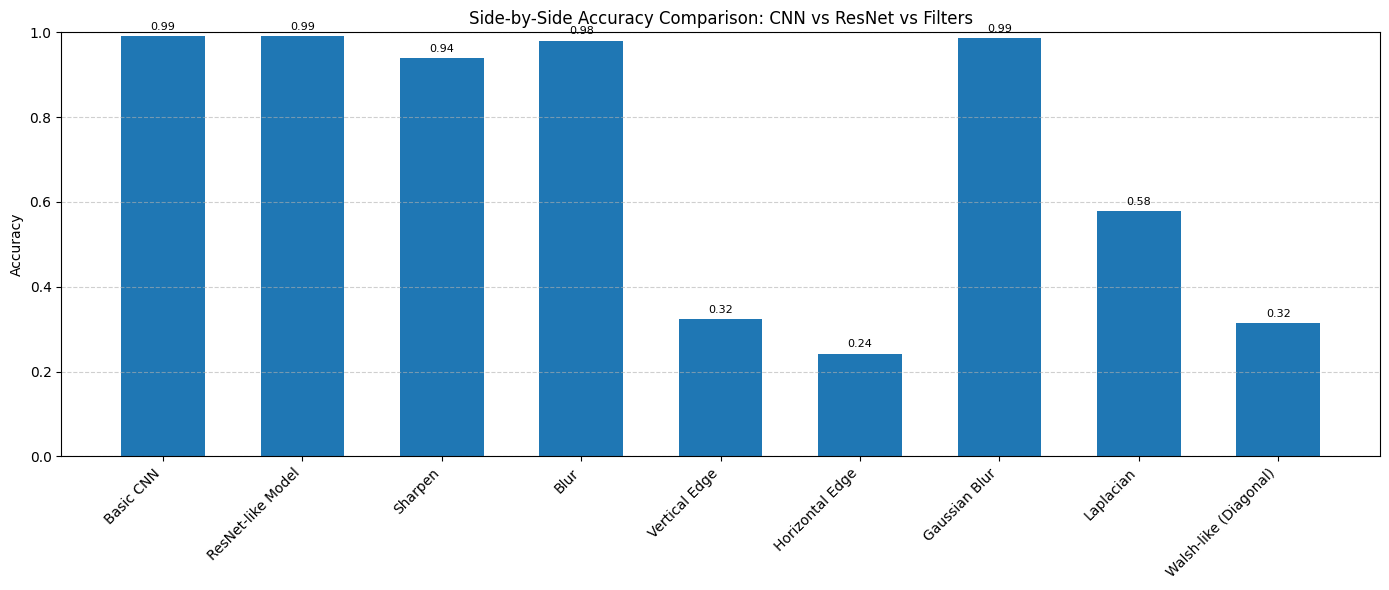

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Model accuracies (already computed earlier)
cnn_acc = cnn_test_acc
resnet_acc = resnet_test_acc

# Filter accuracies (dictionary from earlier)
filter_names = list(filter_accuracies.keys())
filter_accs = list(filter_accuracies.values())

# Combine all labels
labels = ["Basic CNN", "ResNet-like Model"] + filter_names
values = [cnn_acc, resnet_acc] + filter_accs

# Grouping setup
x = np.arange(len(labels))
width = 0.6  # bar width

plt.figure(figsize=(14, 6))
bars = plt.bar(x, values, width)

# Styling
plt.title("Side-by-Side Accuracy Comparison: CNN vs ResNet vs Filters")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.0)
plt.xticks(x, labels, rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate accuracy above bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{height:.2f}",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
